In [1]:
# Load the autoreload extension
%load_ext autoreload

# Set autoreload mode
%autoreload 2

# Dataset Class Exploration

In [2]:
from mermaidseg.datasets.dataset import CoralNetDataset
from mermaidseg.io import _load_csv_if_path

In [3]:
import numpy as np 
import tqdm
from matplotlib import pyplot as plt
import boto3
import warnings

In [4]:
batch_size = 4

padding = 10
concept_mapping_flag = True

whitelist_sources = _load_csv_if_path("../../configs/run1_train_sources.csv")

There was a bug that didn't load CoralNet data, but that was only due to a bug in the base dataset class (BaseCoralDataset) read_image function.

The warning `UserWarning: Truncated File Read` is explored below, and seems to only be a corruption of the metadata (the image itself seems to be read correctly) that so far occurs for very large files (8000x8000 pixels) for a specific source (4009), though it is possible this same problem occurs for other sources that aren't within the original list of training sources. 

In [5]:
dataset_dict = {}

dataset_dict["coralnet"] = CoralNetDataset(concept_mapping_flag=concept_mapping_flag, whitelist_sources=whitelist_sources, padding = padding)

In [6]:
for i in tqdm.tqdm(np.random.randint(0, len(dataset_dict["coralnet"]), 10000)):
    with warnings.catch_warnings(record=True) as caught:
        warnings.filterwarnings("always", category=UserWarning)  # capture only UserWarning
        img, mask = dataset_dict["coralnet"][i]

        if caught:
            w = caught[0]
            print(f"Warning at index {i}: {w.category.__name__}: {w.message}")
            print("Source:", dataset_dict["coralnet"].df_images.loc[i, "source_id"])
            break

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 6/10000 [00:05<2:46:25,  1.00it/s]

Warning at index 58173: UserWarning: Truncated File Read
Source: 4009


In [7]:
dataset_dict["coralnet"].df_images.loc[i]

source_id       4009
image_id     4530098
Name: 58173, dtype: object

In [8]:
dataset_dict["coralnet"].df_images.loc[i]

source_id       4009
image_id     4530098
Name: 58173, dtype: object

In [9]:
img, mask = dataset_dict["coralnet"][i]

/opt/conda/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [10]:
np.min(img), np.max(img), img.shape

(18, 255, (8000, 8000, 3))

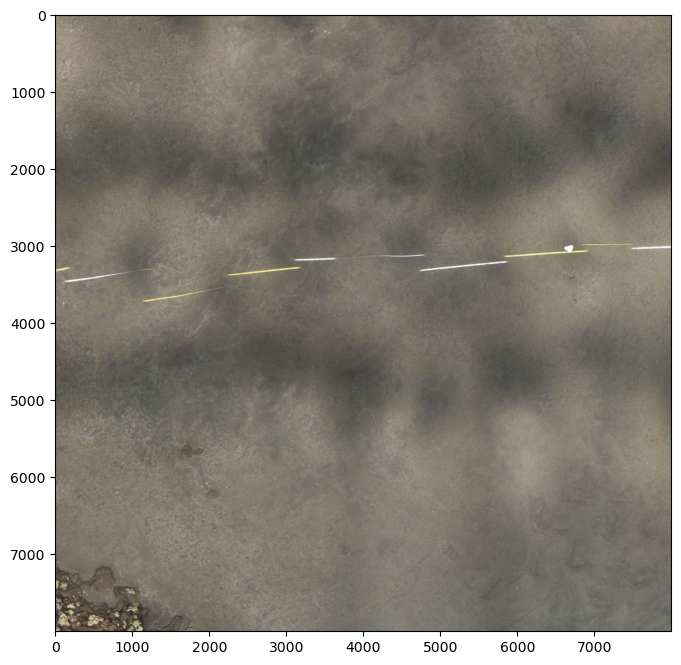

In [11]:
fig, ax = plt.subplots(figsize = (8, 8))
plt.imshow(img)
plt.show()

In [12]:
from mermaidseg.datasets.utils import get_image_s3

source_bucket = "dev-datamermaid-sm-sources"
source_s3_prefix = "coralnet-public-images"

s3 = boto3.client("s3")

key = f"{source_s3_prefix}/s{4009}/images/{4538674}.jpg"
with warnings.catch_warnings(record=True) as w:
    img_test = get_image_s3(s3=s3, bucket=source_bucket, key=key).convert("RGB")
    img_test.verify()
    print([str(x.message) for x in w])

    img_test = get_image_s3(s3=s3, bucket=source_bucket, key=key).convert("RGB")
    img_test.load()

['Truncated File Read']
